# Customer Churn Analysis Prediction
Customer Churn is when an existing customer, user , subscriber, or any kind of client stop doing business with the company.

## Types of Customer Churn
Contractual churn - a customer is under a contract for a service and decides to cancel the service e.g Cable Tv

Voluntary churn - when a user voluntary cancels a service e.g  Cellar connection

Non-Contractual Churn : When a customer is not under a contract for a service and decides to cancel the service e.g. Consumer Loyalty in retail stores

Involuntary Churn : When a churn occurs without any request of the customer e.g. Credit card expiration.

## Reason for Churn
lack of usage

poor service

Better Price


## ?
pip install kaggle



In [48]:
'''
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)
'''

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("blastchar/telco-customer-churn")\n\nprint("Path to dataset files:", path)\n'

# Dataset Preprocessing Steps

## 1. Load the Dataset

In [49]:
import pandas as pd
df = pd.read_csv("c:\\Users\\franc\\.cache\\kagglehub\\datasets\\blastchar\\telco-customer-churn\\versions\\1\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Understand the Dataset


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# 3. Handle Missing or Invalid Values

In [52]:
# TotalCharges is object due to some missing or corrupt values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

# check for nulls
df.isnull().sum()

# Drop or impute nulls
df = df.dropna()


# 4. Drop Irrelevant Columns


In [53]:
df = df.drop(['customerID'], axis = 1)

# 5. Encode Categorical Variables

In [54]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [55]:
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

### multiple categories
pd.get_dummies -  is a function in pandas used to convert categorical variables into dummy/indicator variables (also known as one-hot encoding).

data: DataFrame or Series — The input data.

drop_first: Bool — Whether to drop the first level of each categorical feature to avoid multicollinearity (useful in regression).


This will handle: gender, InternetService, Contract, PaymentMethod and others

In [56]:

df = pd.get_dummies(df, drop_first = True, dtype = int)

# 6. Feature Scaling (optional but helpful)
Use StandardScaler for numeric features like tenure, MonthlyCharges, and TotalCharges.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [58]:
df.head(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,0,...,0,0,0,0,0,0,0,0,1,0


# 7. Split into Features and Target

In [59]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

# 8. Train-Test Split



In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [61]:
print('Train set:', y_train.shape, X_train.shape)
print('Test set:', y_test.shape, X_test.shape)

Train set: (5625,) (5625, 30)
Test set: (1407,) (1407, 30)


# Random Forest model to predict customer churn

In [62]:
# Import Required Libraries
# train
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [94]:
# train the model
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [95]:
# make predictions
y_pred = rf_model.predict(X_test)

In [96]:
#  Evaluate the Model
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[927 106]
 [184 190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407


Accuracy Score: 0.7938877043354655


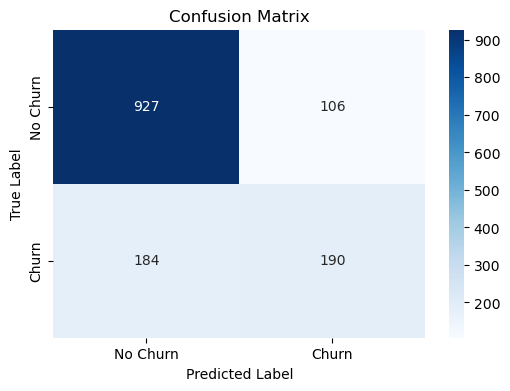

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)  # or y_pred_rf for RandomForest
labels = ['No Churn', 'Churn']

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# visualization

C:\Users\franc\AppData\Local\Temp\ipykernel_3396\801952841.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[:10], y=feature_importance.index[:10], palette="viridis")


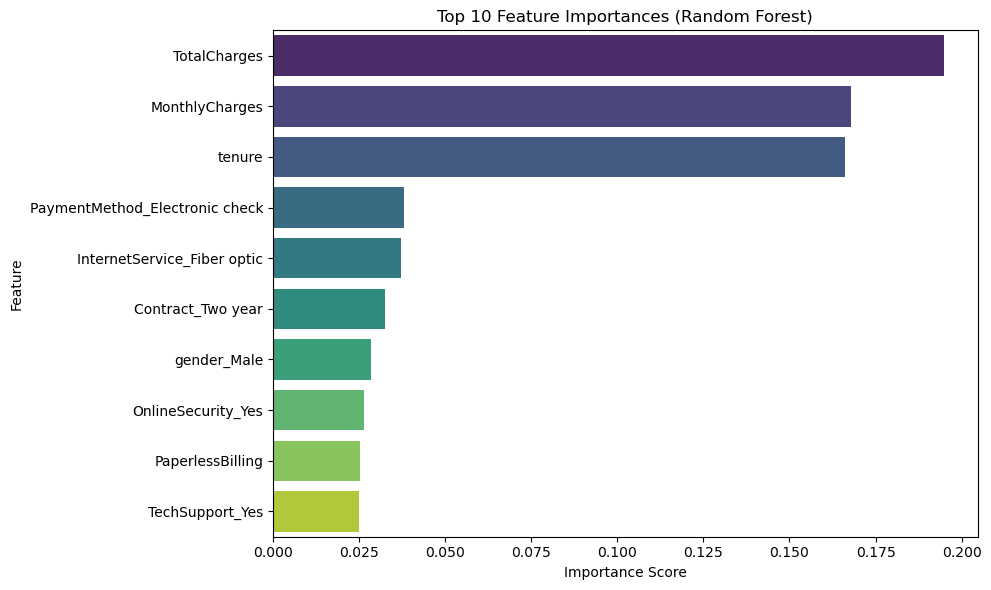

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# get feature importances
feature_importance = pd.Series(rf_model.feature_importances_, index = X.columns).sort_values(ascending= False)

# plot top 10 important features
plt.figure(figsize = (10,6))
sns.barplot(x=feature_importance[:10], y=feature_importance.index[:10], palette="viridis")
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



# 1. Hyperparameter Tuning with Gridsearch

In [67]:
''' 
from sklearn.model_selection import GridSearchCV

# Define the hyperpameter grid

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Instantiate the model
rf = RandomForestClassifier(random_state=42)

# Perform Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='accuracy') 
grid_search.fit(X_train,y_train)

# Best parameters and model
print('Best Parameters:', grid_search.best_params_)

best_rf = grid_search.best_estimator_
print('Best Estimators:', best_rf)
'''


" \nfrom sklearn.model_selection import GridSearchCV\n\n# Define the hyperpameter grid\n\nparam_grid = {\n    'n_estimators': [100, 200, 300],\n    'max_depth': [None, 10, 20,30],\n    'min_samples_split': [2, 5, 10],\n    'min_samples_leaf': [1, 2, 4],\n    'bootstrap': [True, False]\n}\n\n# Instantiate the model\nrf = RandomForestClassifier(random_state=42)\n\n# Perform Grid search\ngrid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='accuracy') \ngrid_search.fit(X_train,y_train)\n\n# Best parameters and model\nprint('Best Parameters:', grid_search.best_params_)\n\nbest_rf = grid_search.best_estimator_\nprint('Best Estimators:', best_rf)\n"

In [68]:
'''
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Estimators: RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,
                       random_state=42)
'''

"\nFitting 5 folds for each of 216 candidates, totalling 1080 fits\nBest Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}\nBest Estimators: RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,\n                       random_state=42)\n"

##  Evaluate the Tuned Model

In [69]:
'''
#  Evaluate the Tuned Model
y_pred_tuned = best_rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_tuned))
'''

'\n#  Evaluate the Tuned Model\ny_pred_tuned = best_rf.predict(X_test)\n\nprint("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))\nprint("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))\nprint("\nAccuracy Score:", accuracy_score(y_test, y_pred_tuned))\n'

In [70]:
'''
Confusion Matrix:
 [[924 109]
 [187 187]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Accuracy Score: 0.7896233120113717
'''

'\nConfusion Matrix:\n [[924 109]\n [187 187]]\n\nClassification Report:\n               precision    recall  f1-score   support\n\n           0       0.83      0.89      0.86      1033\n           1       0.63      0.50      0.56       374\n\n    accuracy                           0.79      1407\n   macro avg       0.73      0.70      0.71      1407\nweighted avg       0.78      0.79      0.78      1407\n\n\nAccuracy Score: 0.7896233120113717\n'

# 2. XGBoost Classifier
pip install xgboost - on terminal

In [74]:
import xgboost as xgb
from xgboost import XGBClassifier


In [75]:
# Train XGBoost model
xgb_model = XGBClassifier(random_state = 42, use_label_encoder = False, eval_metric = 'logloss')
xgb_model.fit(X_train,y_train)

# predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.7782515991471215

Confusion Matrix:
 [[890 143]
 [169 205]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



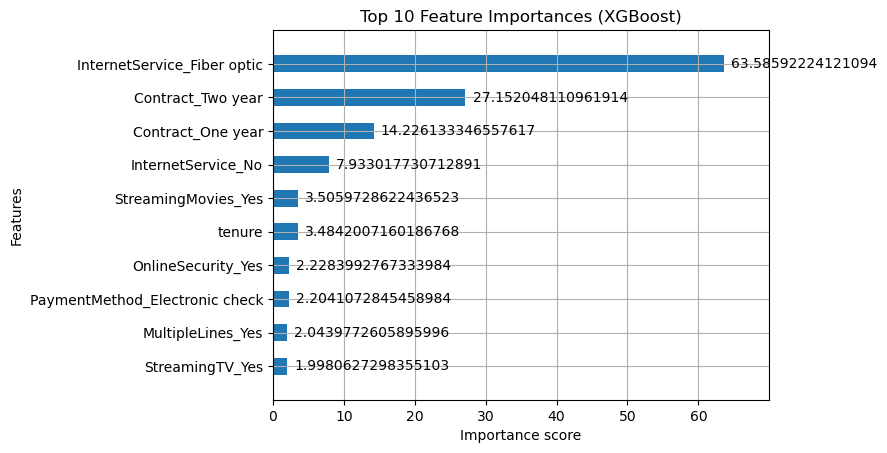

In [76]:
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', height=0.5)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()